In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, filters, measure, morphology
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte

<class 'numpy.ndarray'>
(303, 384)
1 252


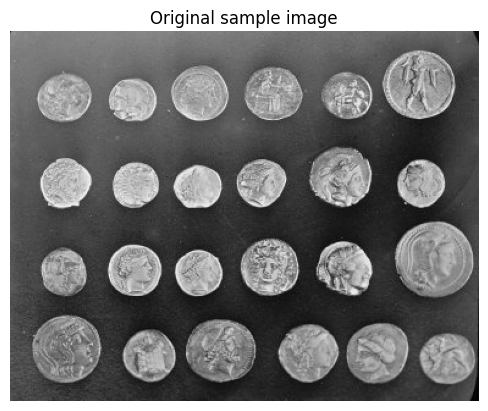

In [2]:
image = data.coins()

print(type(image))
print(image.shape)
print(image.min(), image.max())

plt.imshow(image, cmap="gray")
plt.title("Original sample image")
plt.axis("off")
plt.show()

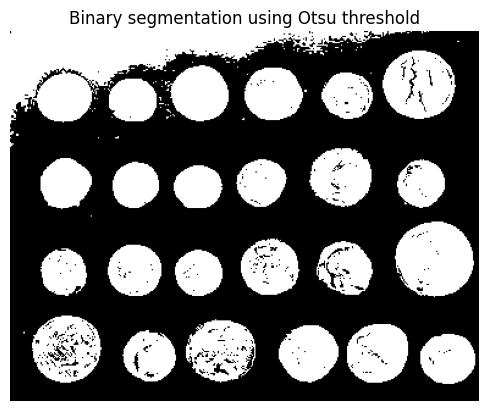

Threshold value: 107


In [3]:
threshold_value = filters.threshold_otsu(image)
binary_image = image > threshold_value

plt.imshow(binary_image, cmap="gray")
plt.title("Binary segmentation using Otsu threshold")
plt.axis("off")
plt.show()

print("Threshold value:", threshold_value)

/tmp/ipykernel_14133/3535056963.py:1: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_image = morphology.remove_small_objects(binary_image, min_size=64)
/tmp/ipykernel_14133/3535056963.py:2: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_image = morphology.remove_small_holes(cleaned_image, area_t

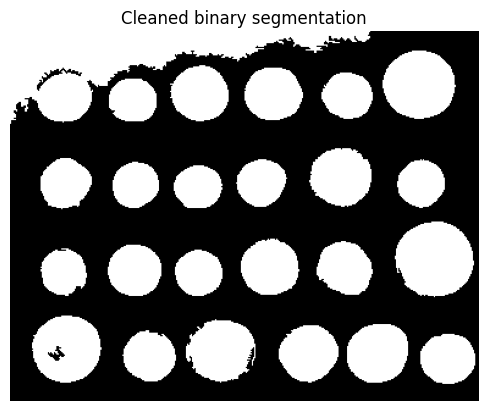

In [4]:
cleaned_image = morphology.remove_small_objects(binary_image, min_size=64)
cleaned_image = morphology.remove_small_holes(cleaned_image, area_threshold=64)

plt.imshow(cleaned_image, cmap="gray")
plt.title("Cleaned binary segmentation")
plt.axis("off")
plt.show()

In [5]:
labeled_image = measure.label(cleaned_image)
regions = measure.regionprops(labeled_image, intensity_image=image)

print("Number of detected regions:", len(regions))

Number of detected regions: 24


In [6]:
features = []

for region in regions:
    if region.area >= 100:
        features.append({
            "label": region.label,
            "area": region.area,
            "perimeter": region.perimeter,
            "mean_intensity": region.mean_intensity,
            "centroid_row": region.centroid[0],
            "centroid_col": region.centroid[1]
        })

feature_summary = pd.DataFrame(features)
feature_summary.head()

/tmp/ipykernel_14133/1535383454.py:9: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  "mean_intensity": region.mean_intensity,


,label,area,perimeter,mean_intensity,centroid_row,centroid_col
0,1,8897.0,1046.133080,126.686636,22.738564,91.727436
1,2,2606.0,188.752309,156.831159,43.457790,334.597467
2,3,1684.0,154.160426,168.416865,50.766033,155.141924
3,4,1639.0,150.124892,157.239780,51.021965,215.142160
4,5,1232.0,132.225397,154.126623,52.424513,275.986201


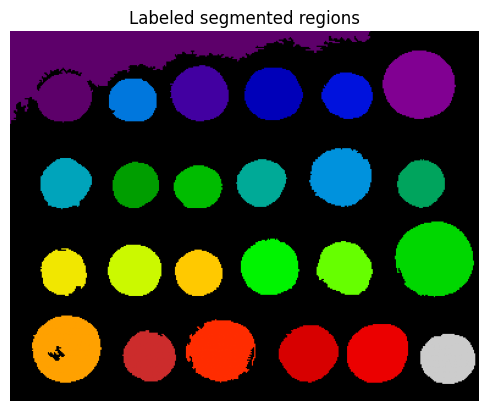

In [7]:
from pathlib import Path

# Create outputs folder one level above notebooks/
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

# Save CSV
feature_summary.to_csv(output_dir / "feature_summary.csv", index=False)

# Save segmented image
plt.imshow(labeled_image, cmap="nipy_spectral")
plt.title("Labeled segmented regions")
plt.axis("off")
plt.savefig(output_dir / "segmented_regions.png", dpi=300, bbox_inches="tight")
plt.show()